# Total_Probability_Theorem

## 1. Why Total Probability?

Sometimes an event can happen through multiple different paths.

If we want the probability of an event (A), instead of calculating it directly, we calculate:

* Probability of (A) happening through path 1
* Probability of (A) happening through path 2
* Probability of (A) happening through path 3
* Add them together

This idea is called the **Law (Theorem) of Total Probability**.

---

### Example

Suppose:

* 60% of students study from Notes
* 40% study from Videos

Pass probabilities:

* Notes students pass with probability 0.8
* Video students pass with probability 0.6

Question:

What is probability that a randomly chosen student passes?

There are only two ways to pass:

1. Studied Notes and passed
2. Studied Videos and passed

So,

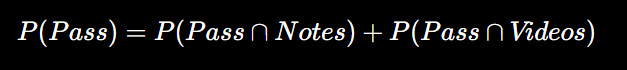

---

Using conditional probability:

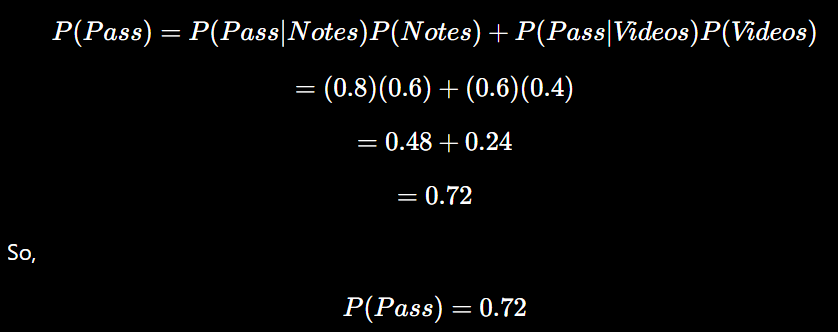

---

## Key Idea

When an event can occur through multiple mutually exclusive paths:

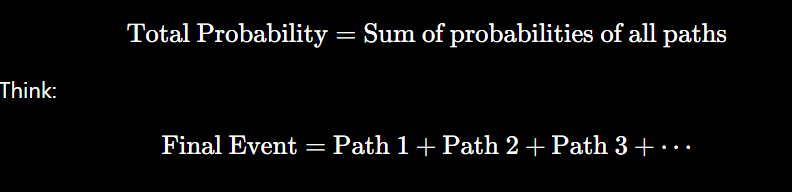

---

### ML Connection

Many Bayesian models first calculate:

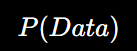

by summing over all possible classes.

Example:

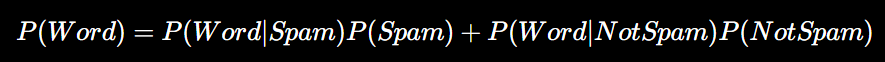


This is Total Probability and is later used in Bayes Theorem.

# Multiple Ways an Event Can Occur

This is the idea that leads directly to Total Probability.

---

## Case 1: Single Way

Suppose you toss a coin.

Event:

**`A = Getting Head`**

Only one path exists:

```
Coin
 └── Head
```

No need for Total Probability.

---

## Case 2: Multiple Ways

Suppose a product is manufactured by:

* Machine A → 50%
* Machine B → 30%
* Machine C → 20%

Event:

**`D = Defective Product`**

A defective product can come from:

```
Defective
├── Machine A
├── Machine B
└── Machine C
```

So there are multiple paths to the same event.

---

## Important Requirement

The paths must be:

### 1. Mutually Exclusive

They cannot happen together.

Example:

A product cannot be produced by both Machine A and Machine B simultaneously.

So:

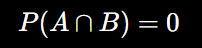

---

### 2. Collectively Exhaustive

All possibilities must be covered.

Example:

Every product comes from either:

* A
* B
* C

No fourth machine exists.

So:

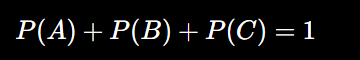

---

## General Idea

Suppose events:

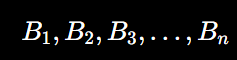

cover all possible cases.

Then event (A) can happen through:

[
A\cap B_1
]

or

[
A\cap B_2
]

or

[
A\cap B_3
]

...

or

[
A\cap B_n
]

Hence

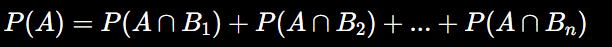

This is the foundation of Total Probability.

---

## Visualization

```
          A
         /|\
        / | \
      B1 B2 B3
```

Event (A) is reached through several different paths.

Total probability simply adds the probabilities of all those paths.

---

### ML Connection

In classification:

Suppose classes are:

* Spam
* Not Spam

An email containing the word "free" can occur through:

```
Word=free
├── Spam
└── Not Spam
```

Later we calculate:

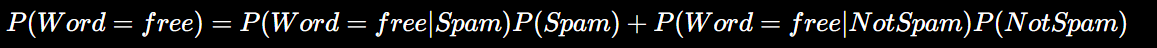

Again, multiple paths leading to the same event.

# Formula

After understanding that an event can occur through multiple mutually exclusive paths, we get the Total Probability Formula.

Suppose:

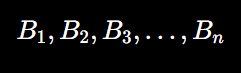

are:

* Mutually Exclusive
* Collectively Exhaustive

Then for any event (A),

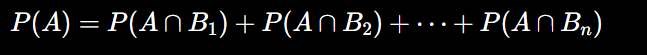

---

Using Conditional Probability:

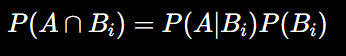

Substituting:

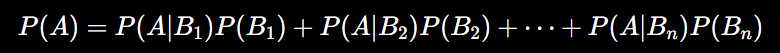

This is the **Law of Total Probability**.

---

## Two-Path Version

Most commonly you'll see:

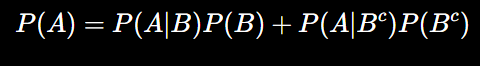

where

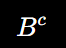

means "not B".

---

## Example

Factory:

* Machine A = 70%
* Machine B = 30%

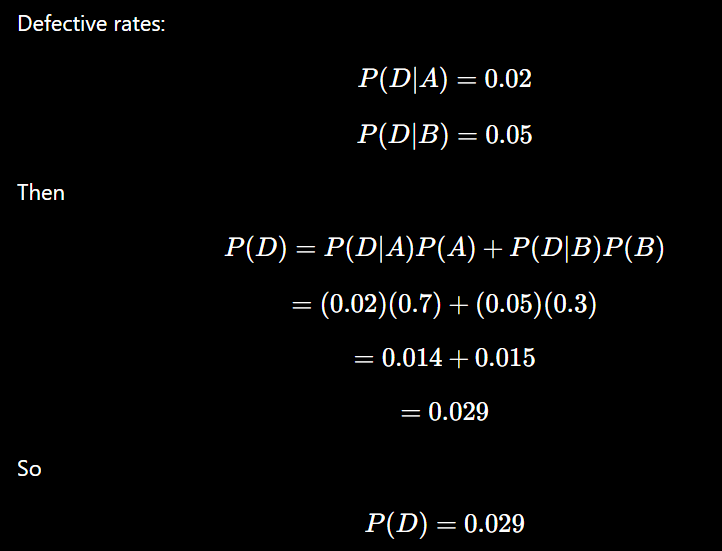

---

## What to Memorize

Just remember:

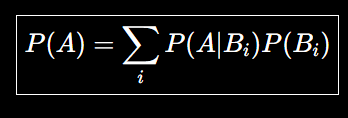

Read it as:

> Probability of event A = sum of probability of A through every possible path.

---

### ML Connection

Naive Bayes often needs:

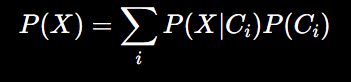

where (C_i) are classes.

This is exactly the Total Probability Formula.

# Tree Diagram Intuition

A tree diagram is the easiest way to visualize Total Probability.

Instead of memorizing formulas, think of probabilities flowing through branches.

---

## Example

Suppose:

* 60% students study Notes
* 40% students study Videos

Pass probabilities:

* (P(Pass|Notes)=0.8)
* (P(Pass|Videos)=0.6)

Tree:

```text
                    Start
                   /     \
               Notes     Videos
               0.6        0.4
              /   \      /    \
          Pass Fail  Pass  Fail
          0.8  0.2   0.6   0.4
```

---

## Step 1: Find Path Probabilities

For a complete path:

[
P(A\cap B)
==========

P(A|B)P(B)
]

So:

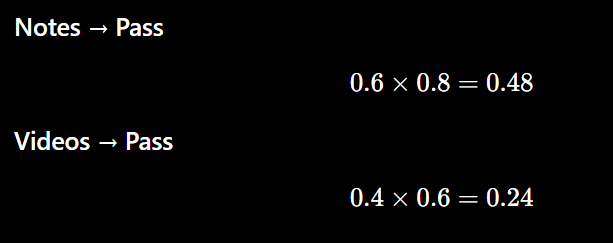

---

## Step 2: Add Paths Leading to Desired Event

Pass can happen through:

```text
Notes → Pass
Videos → Pass
```

Therefore

[
P(Pass)
=======

0.48 + 0.24
]

[
=0.72
]

This is Total Probability.

---

## General Tree

```text
                 Start
             /     |      \
           B1      B2      B3
          /        |        \
         A         A         A
```

Then

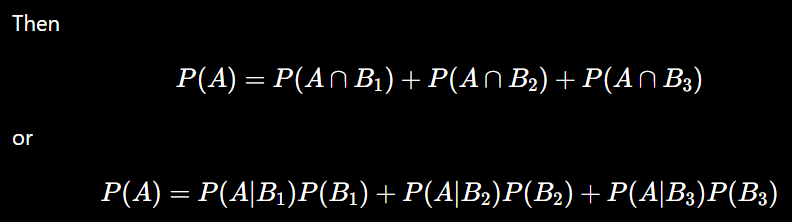

---

## Why Trees Are Useful

Whenever you see:

* Multiple stages
* Multiple choices
* Conditional probabilities

draw a tree.

Then:

1. Multiply along a branch.
2. Add branches that lead to the same final event.

That's exactly Total Probability.

---

### ML Connection

For a spam filter:

```text
                Email
              /       \
           Spam    Not Spam
            |          |
         Word X     Word X
```

To find probability of seeing Word X:

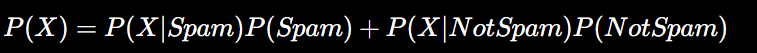

# Python Examples

Let's see how to implement Total Probability in Python.

---

## Example 1: Exam Passing

Given:

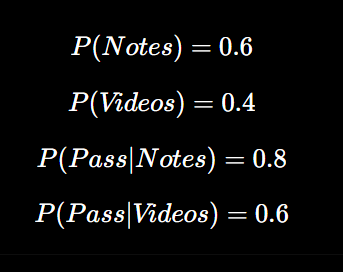


```python
p_notes = 0.6
p_videos = 0.4

p_pass_given_notes = 0.8
p_pass_given_videos = 0.6

p_pass = (
    p_pass_given_notes * p_notes
    + p_pass_given_videos * p_videos
)

print(p_pass)
```

Output:

```python
0.72
```

---

## Example 2: Factory Defects

```python
p_A = 0.7
p_B = 0.3

p_defect_given_A = 0.02
p_defect_given_B = 0.05

p_defect = (
    p_defect_given_A * p_A
    + p_defect_given_B * p_B
)

print(p_defect)
```

Output:

```python
0.029
```

---

## Example 3: Generic Total Probability

Suppose there are many paths.

```python
path_probs = [0.5, 0.3, 0.2]

conditional_probs = [0.8, 0.6, 0.4]

total_prob = sum(
    p_a_given_b * p_b
    for p_a_given_b, p_b in zip(conditional_probs, path_probs)
)

print(total_prob)
```

Output:

```python
0.66
```

Calculation:

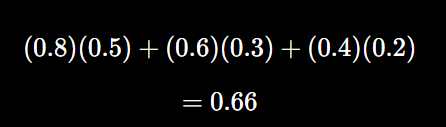

---

## NumPy Version

```python
import numpy as np

p_b = np.array([0.5, 0.3, 0.2])

p_a_given_b = np.array([0.8, 0.6, 0.4])

p_a = np.sum(p_b * p_a_given_b)

print(p_a)
```

Output:

```python
0.66
```

---

## ML Connection

In Naive Bayes we often compute:

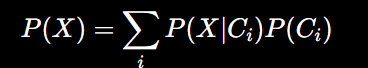

Python implementation:

```python
import numpy as np

priors = np.array([0.3, 0.7])

likelihoods = np.array([0.8, 0.2])

evidence = np.sum(priors * likelihoods)

print(evidence)
```

Here:

* `priors` = (P(C_i))
* `likelihoods` = (P(X|C_i))
* `evidence` = (P(X))

This evidence term comes directly from the Law of Total Probability.